In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignorer les warnings de convergence pour la clarté de l'exécution
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
# ==========================================
# 1. Génération du dataset bruité
# ==========================================
print("Génération du dataset...")
X, y = make_classification(
    n_samples=3000, 
    n_features=50, 
    n_informative=15, 
    n_redundant=10, 
    n_classes=2, 
    flip_y=0.1, # Ajout de bruit (10% des labels inversés)
    random_state=42
)
# ==========================================
# 2. Split train / test (80 / 20)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Génération du dataset...


In [6]:
# ==========================================
# 3. Définition des paramètres
# ==========================================
degrees = [2, 3]
penalties = [None, 'l1', 'l2'] 
# Note : scikit-learn récent utilise penalty=None au lieu de 'none'

def get_model(penalty):
    """Retourne le bon solveur en fonction de la pénalité."""
    if penalty == 'l1':
        return LogisticRegression(penalty=penalty, solver='saga', max_iter=50, random_state=42, n_jobs=-1)
    else:
        return LogisticRegression(penalty=penalty, solver='lbfgs', max_iter=50, random_state=42, n_jobs=-1)

def build_pipeline(degree, penalty):
    """Crée un pipeline : Scaler -> Poly -> Scaler -> LogReg."""
    return Pipeline([
        ('scaler1', StandardScaler()), # Standardisation initiale
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler2', StandardScaler()), # Re-standardisation après Poly pour aider le solveur
        ('logreg', get_model(penalty))
    ])

In [7]:
# ==========================================
# 4. Entraînement + calcul des accuracies
# ==========================================
print("Entraînement des modèles en cours (cela peut prendre un moment pour le degré 3)...")
results = {2: {}, 3: {}}

for deg in degrees:
    for pen in penalties:
        pipe = build_pipeline(deg, pen)
        pipe.fit(X_train, y_train)
        
        acc_train = pipe.score(X_train, y_train)
        acc_test = pipe.score(X_test, y_test)
        
        pen_name = "Aucune" if pen is None else pen.upper()
        results[deg][pen_name] = {'train': acc_train, 'test': acc_test}
        print(f"Degré {deg} | Pénalité {pen_name:6} -> Train Acc: {acc_train:.3f}, Test Acc: {acc_test:.3f}")

Entraînement des modèles en cours (cela peut prendre un moment pour le degré 3)...
Degré 2 | Pénalité Aucune -> Train Acc: 1.000, Test Acc: 0.777
Degré 2 | Pénalité L1     -> Train Acc: 0.960, Test Acc: 0.852
Degré 2 | Pénalité L2     -> Train Acc: 1.000, Test Acc: 0.775
Degré 3 | Pénalité Aucune -> Train Acc: 1.000, Test Acc: 0.848
Degré 3 | Pénalité L1     -> Train Acc: 0.990, Test Acc: 0.845
Degré 3 | Pénalité L2     -> Train Acc: 1.000, Test Acc: 0.843


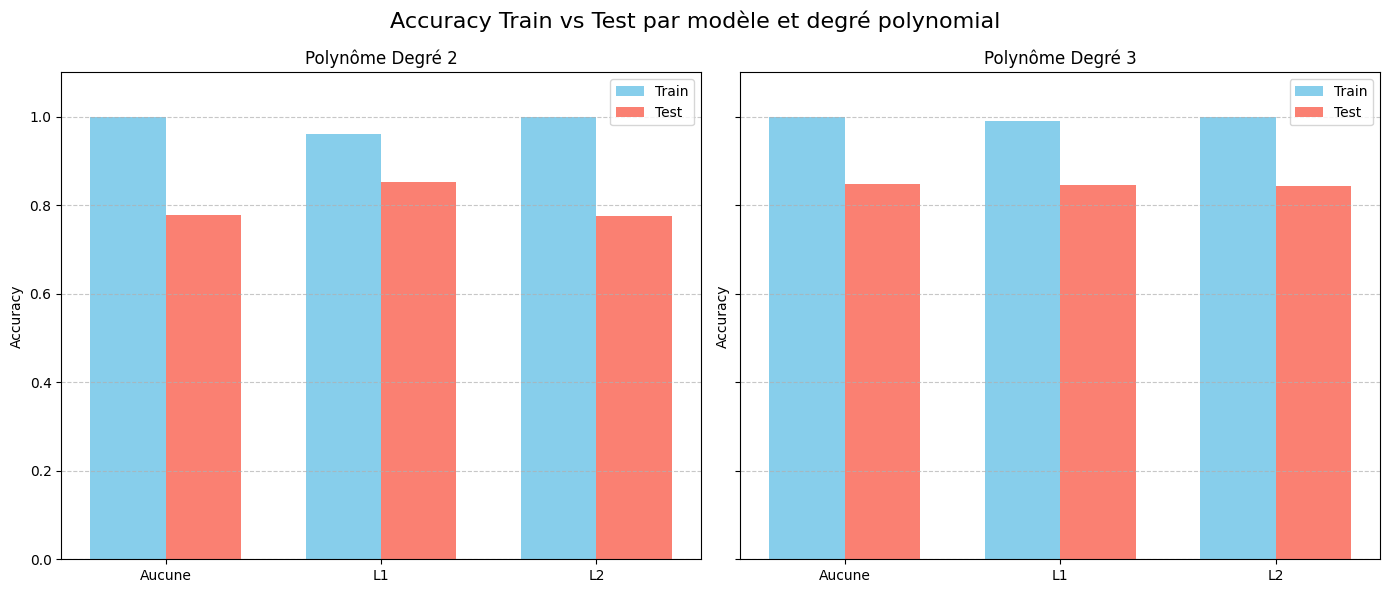

In [8]:
# ==========================================
# 5. Graphique : Accuracy train vs test
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Accuracy Train vs Test par modèle et degré polynomial", fontsize=16)

x_labels = ["Aucune", "L1", "L2"]
x = np.arange(len(x_labels))
width = 0.35

for i, deg in enumerate(degrees):
    ax = axes[i]
    train_scores = [results[deg][pen]['train'] for pen in x_labels]
    test_scores = [results[deg][pen]['test'] for pen in x_labels]
    
    ax.bar(x - width/2, train_scores, width, label='Train', color='skyblue')
    ax.bar(x + width/2, test_scores, width, label='Test', color='salmon')
    
    ax.set_title(f"Polynôme Degré {deg}")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Génération des frontières de décision (sur projection 2D)...


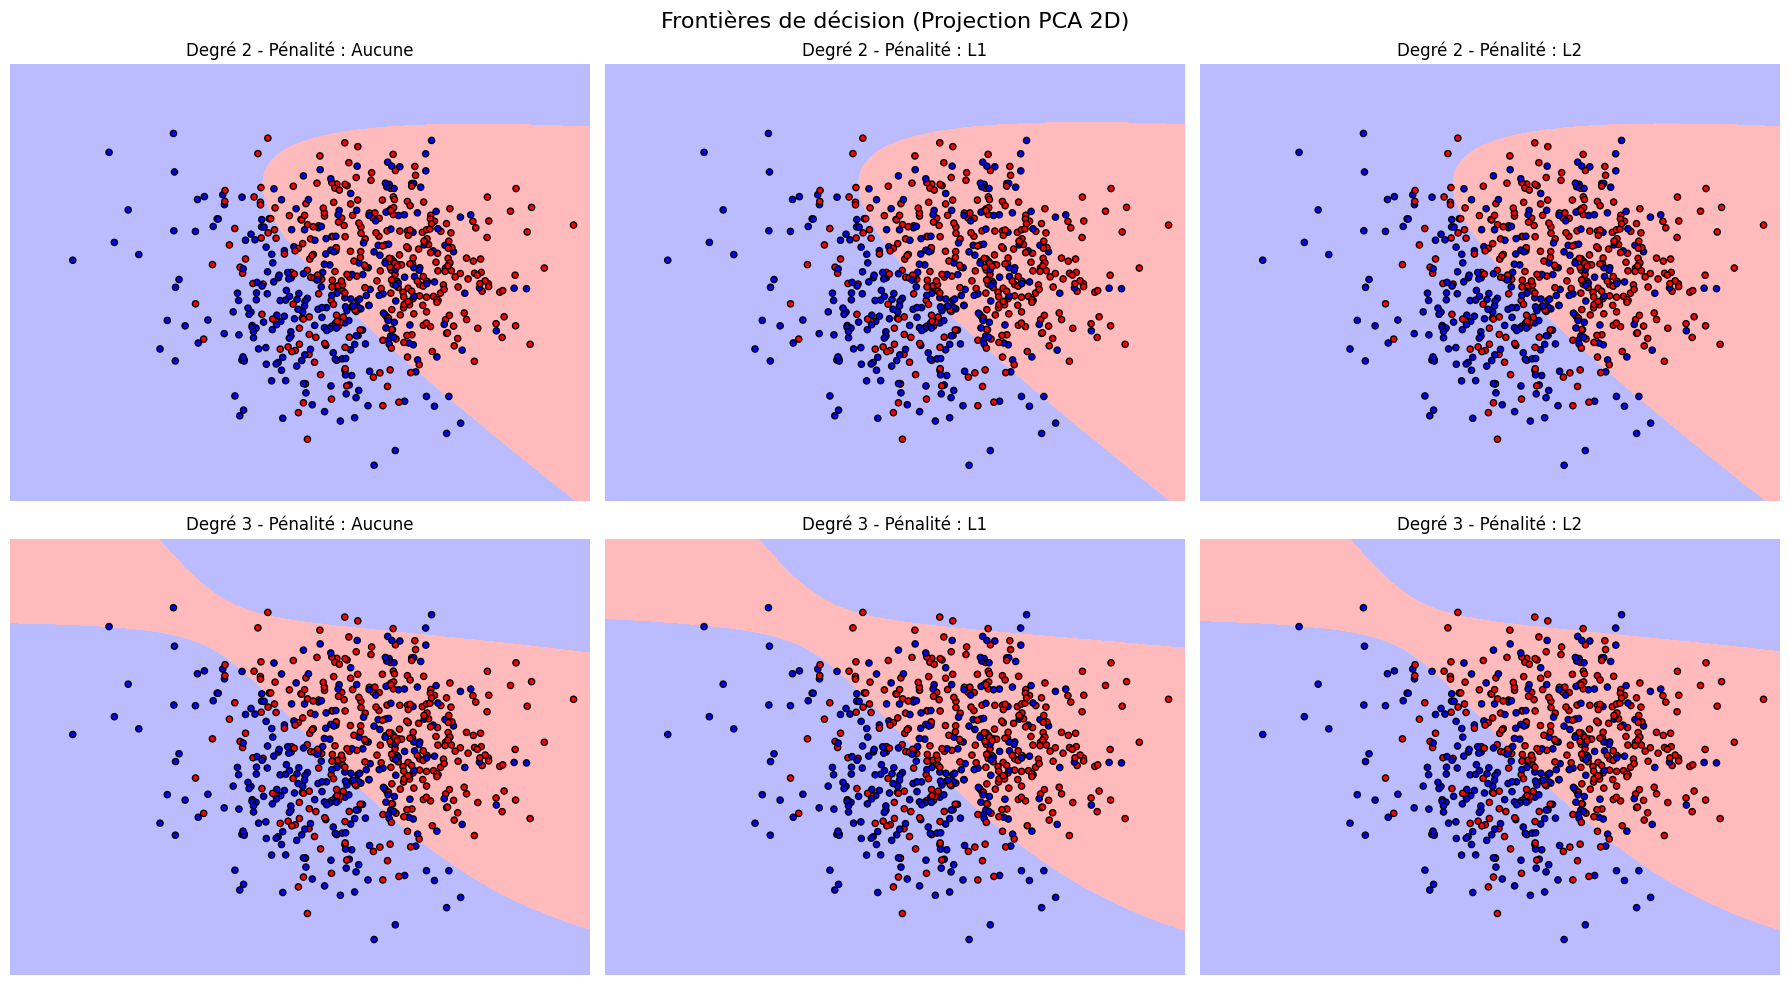

In [9]:
# ==========================================
# 6. Frontières de décision (avec réduction PCA 2D)
# ==========================================
print("Génération des frontières de décision (sur projection 2D)...")
# Réduction à 2 composantes pour pouvoir visualiser en 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

h = .02  # Pas du maillage
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Frontières de décision (Projection PCA 2D)", fontsize=16)

cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

for i, deg in enumerate(degrees):
    for j, pen in enumerate(penalties):
        ax = axes[i, j]
        pen_name = "Aucune" if pen is None else pen.upper()
        
        # Entraînement sur données 2D
        pipe_2d = build_pipeline(deg, pen)
        pipe_2d.fit(X_train_pca, y_train_pca)
        
        # Prédiction sur le maillage
        Z = pipe_2d.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        # Affichage
        ax.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.8)
        ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pca, cmap=cmap_bold, edgecolor='k', s=20)
        ax.set_title(f"Degré {deg} - Pénalité : {pen_name}")
        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.axis('off')

plt.tight_layout()
plt.show()

Génération des courbes d'apprentissage...


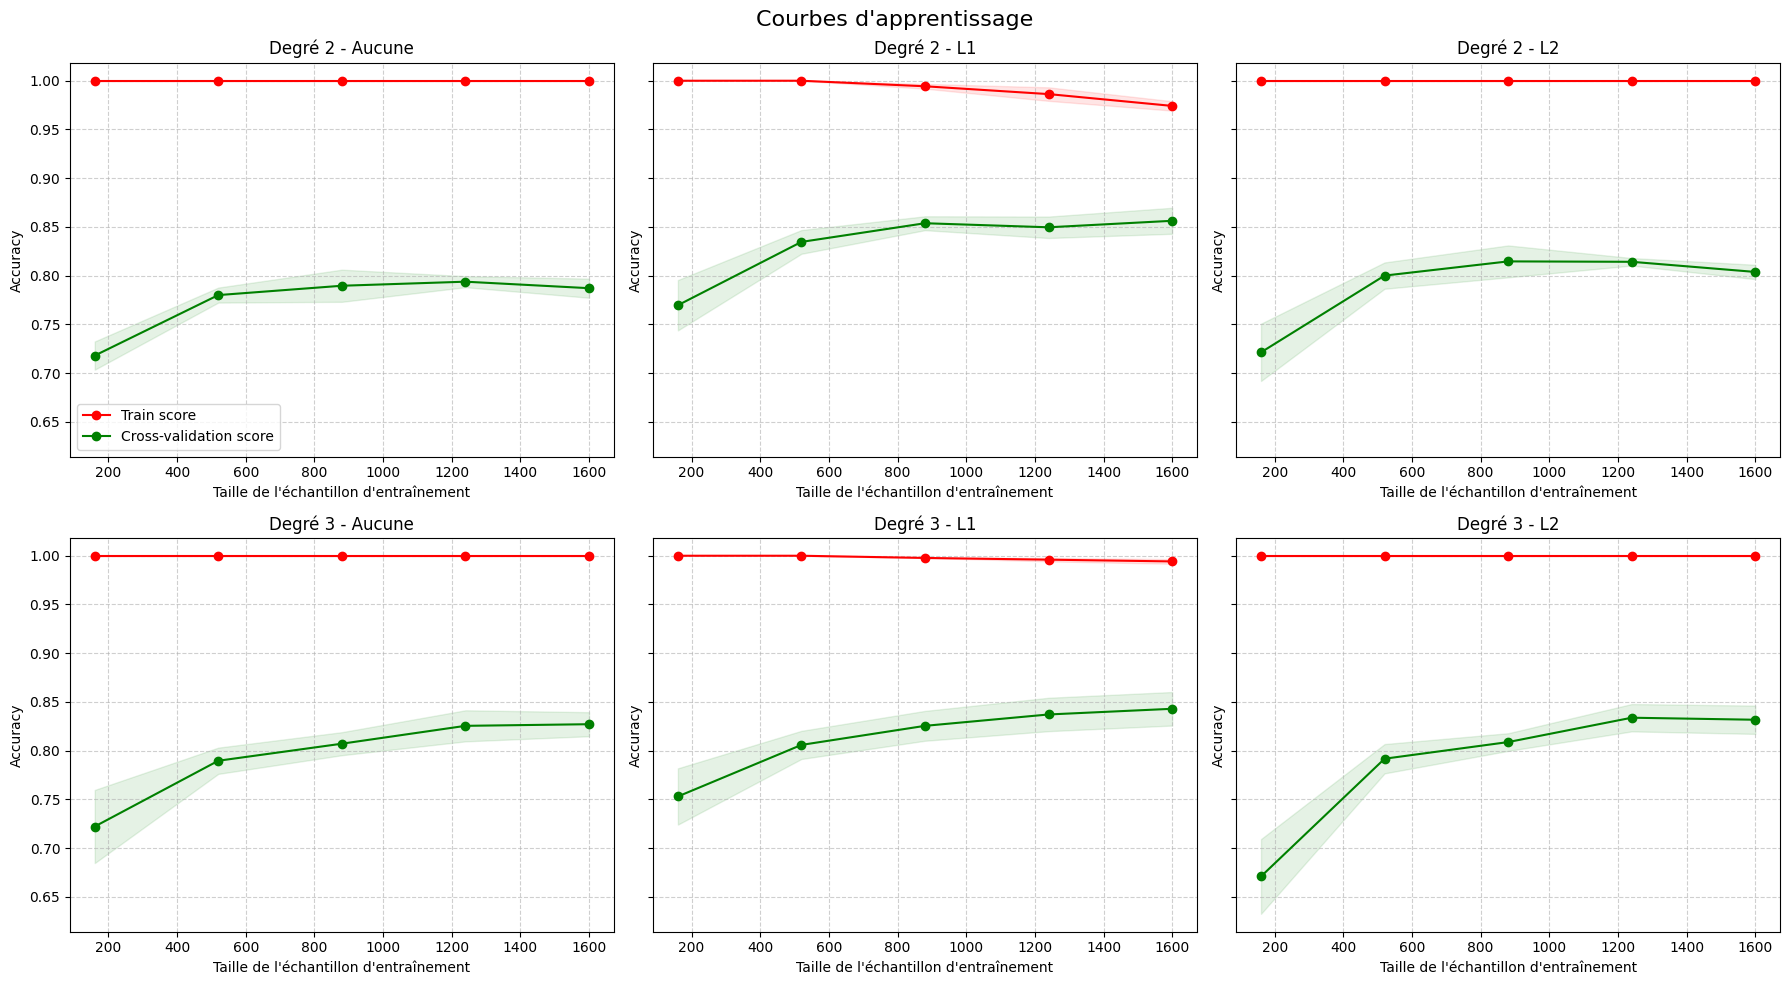

In [10]:
# ==========================================
# 7. Courbes d'apprentissage
# ==========================================
print("Génération des courbes d'apprentissage...")
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("Courbes d'apprentissage", fontsize=16)

train_sizes_config = np.linspace(0.1, 1.0, 5)

for i, deg in enumerate(degrees):
    for j, pen in enumerate(penalties):
        ax = axes[i, j]
        pen_name = "Aucune" if pen is None else pen.upper()
        
        pipe = build_pipeline(deg, pen)
        
        # Calcul des learning curves (cv=3 pour gagner du temps, surtout pour deg 3)
        train_sizes, train_scores, test_scores = learning_curve(
            pipe, X_train, y_train, cv=3, n_jobs=-1, 
            train_sizes=train_sizes_config, scoring='accuracy'
        )
        
        train_scores_mean = np.mean(train_scores, axis=1)
        train_scores_std = np.std(train_scores, axis=1)
        test_scores_mean = np.mean(test_scores, axis=1)
        test_scores_std = np.std(test_scores, axis=1)
        
        ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1, color="r")
        ax.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1, color="g")
        ax.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Train score")
        ax.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
        
        ax.set_title(f"Degré {deg} - {pen_name}")
        ax.set_xlabel("Taille de l'échantillon d'entraînement")
        ax.set_ylabel("Accuracy")
        ax.grid(True, linestyle='--', alpha=0.6)
        if i == 0 and j == 0:
            ax.legend(loc="best")

plt.tight_layout()
plt.show()